In [1]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def extract_mfcc_features(file_path, n_mfcc=20, max_pad_len=400):
    # 1. Load the audio file (Resample to 22kHz for consistency)
    audio, sr = librosa.load(file_path, res_type='kaiser_fast', sr=22050)
    
    # 2. Extract MFCCs
    # n_mfcc=20 is standard; higher captures more fine-grained "voice quality"
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
    
    # 3. Extract Delta (Velocity) and Delta-Delta (Acceleration)
    # These are crucial for detecting the "hesitations" in Alzheimer's speech
    delta_mfccs = librosa.feature.delta(mfccs)
    delta2_mfccs = librosa.feature.delta(mfccs, order=2)
    
    # 4. Concatenate them into a single feature map (Stacking vertically)
    # This creates a 60-feature height image (20 MFCC + 20 Delta + 20 Delta2)
    comprehensive_mfcc = np.concatenate((mfccs, delta_mfccs, delta2_mfccs), axis=0)
    
    # 5. Padding/Truncating (Ensures all images are the same size for the CNN)
    if (comprehensive_mfcc.shape[1] < max_pad_len):
        pad_width = max_pad_len - comprehensive_mfcc.shape[1]
        comprehensive_mfcc = np.pad(comprehensive_mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        comprehensive_mfcc = comprehensive_mfcc[:, :max_pad_len]
    
    return comprehensive_mfcc



c:\ProgramData\miniconda3\envs\pause-test\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


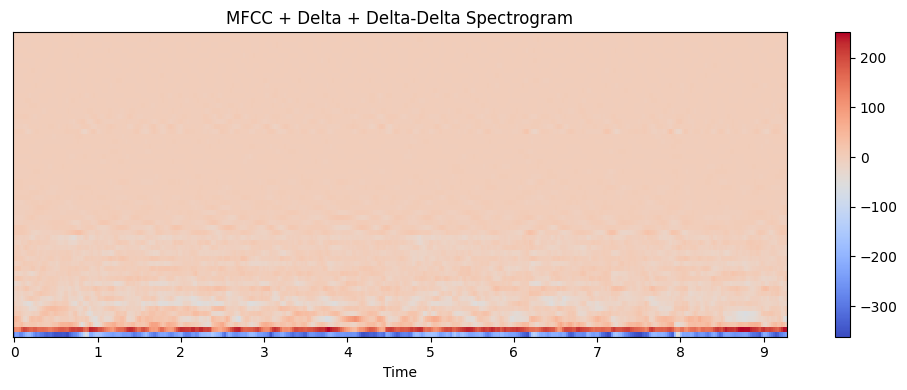

In [3]:
# --- Visualization for Debugging ---
def plot_mfcc(mfcc_data):
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mfcc_data, x_axis='time')
    plt.colorbar()
    plt.title('MFCC + Delta + Delta-Delta Spectrogram')
    plt.tight_layout()
    plt.show()

# Example usage:
features = extract_mfcc_features(r'E:\ML\silero-python\patient_audio_segments\combined_patient_audio.wav')
plot_mfcc(features)

In [ ]:
def extract_multimodal_features(file_path):
    audio, sr = librosa.load(file_path, sr=22050)
    
    # MFCC for timbre/quality
    mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=20)
    
    # Jitter for pitch variation
    f0, _, _ = librosa.pyin(audio, fmin=50, fmax=400)
    f0_voiced = f0[~np.isnan(f0)]
    jitter = np.mean(np.abs(np.diff(f0_voiced))) / np.mean(f0_voiced) if len(f0_voiced) > 1 else 0
    
    # Energy for intensity/emphasis
    energy = librosa.feature.rms(y=audio)[0]
    
    # Onset detection for speech pauses
    onset_frames = librosa.onset.onset_detect(y=audio, sr=sr)
    pause_duration = np.mean(np.diff(librosa.frames_to_time(onset_frames, sr=sr)))
    
    return {
        # 'mfcc': mfccs,
        'jitter': jitter,
        'energy': energy,
        'pause_duration': pause_duration
    }

f = extract_mfcc_features(r'E:\ML\silero-python\demantia_bank\Baycrest2103.mp3')


print(f)



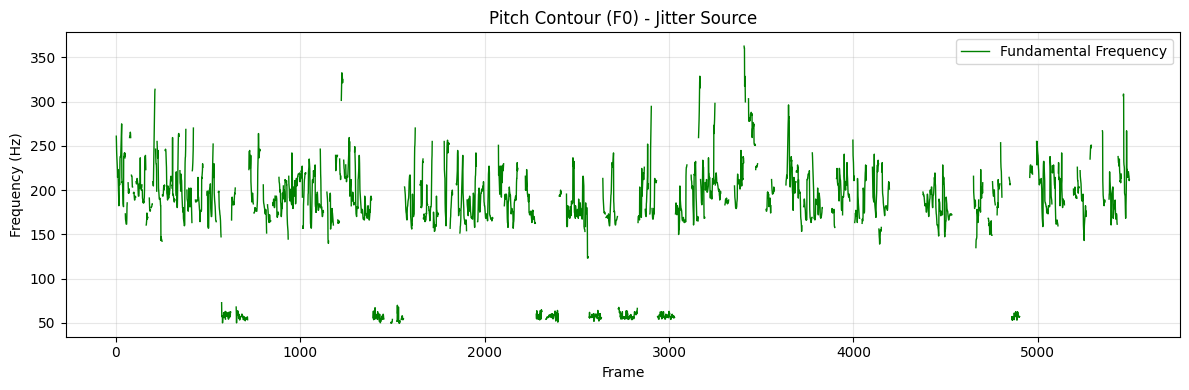

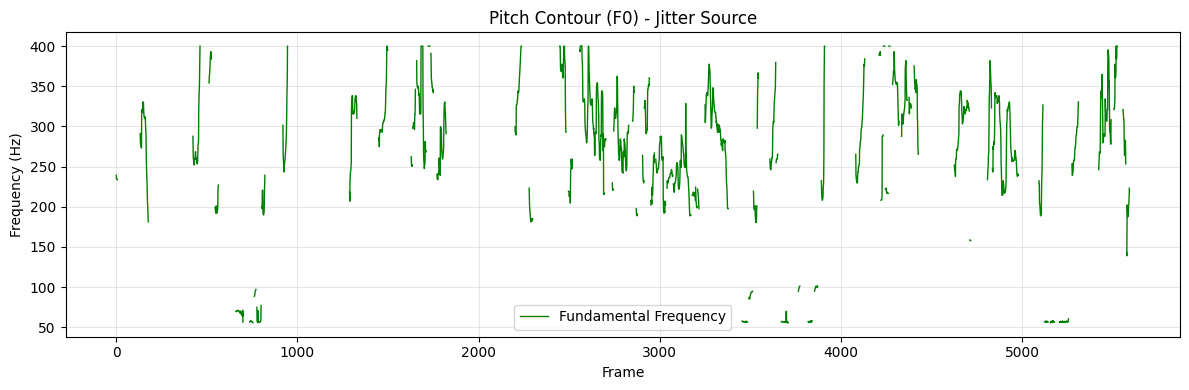

In [11]:
def plot_jitter(file_path):
    audio, sr = librosa.load(file_path, sr=22050)
    f0, _, _ = librosa.pyin(audio, fmin=50, fmax=400)
    
    plt.figure(figsize=(12, 4))
    plt.plot(f0, linewidth=1, color='green', label='Fundamental Frequency')
    plt.xlabel('Frame')
    plt.ylabel('Frequency (Hz)')
    plt.title('Pitch Contour (F0) - Jitter Source')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_jitter(r'E:\ML\silero-python\patient_audio_segments\combined_patient_audio.wav')
plot_jitter(r'E:\ML\silero-python\demantia_bank\010-4.mp3')